In [ ]:
import pandas as pd

In [ ]:
csv_es = "es_data.csv"

es_df = pd.read_csv(csv_es)
es_df.head(2)

,id,course_of_study,full_bio,full_image_url,industries,name,organisation,role,school,thumbnail_image_url,wave_id,last_modified_time
0,reclM5g8XAgk138Q1,Mechanical Engineering,"Chinmay Gavankar is Director, Data and Artific...",https://advisorysg-mentorship.s3.ap-southeast-...,['Information and Communications Technology' '...,Chinmay Gavankar,Microsoft Corporation,Director-Data & AI,VJTI University of Mumbai,https://advisorysg-mentorship.s3.ap-southeast-...,2023,2023-07-24T15:01:44.000Z
1,recuMGexISFZy6MkF,"Master of Business Administration, B.Eng in Me...",Denis Koh is the Professional Service Director...,https://advisorysg-mentorship.s3.ap-southeast-...,['Information and Communications Technology' '...,Denis Koh,"Aptos Software Singapore,",Professional Service Director,"University of Technology, Syndey, Nanyang Tech...",https://advisorysg-mentorship.s3.ap-southeast-...,2021-2,2023-04-01T01:25:57.000Z


In [ ]:
# extract only id and name from es_df
es_df = es_df[['id', 'name']]
es_df.head()

,id,name
0,reclM5g8XAgk138Q1,Chinmay Gavankar
1,recuMGexISFZy6MkF,Denis Koh
2,rec7OJSBJ8rCSqJRI,Choon Yin Yee
3,recP44ctWCcSvn1Qr,Derek Chee
4,rec5gZPt1aMIwwmtG,Christian Xia


In [ ]:
csv_file_path = "es_mentor_with_keywords.csv"

df = pd.read_csv(csv_file_path)
df.head(2)

,Unnamed: 0,id,full_bio,industries,organisation,combined_keywords
0,0,reclM5g8XAgk138Q1,"Chinmay Gavankar is Director, Data and Artific...",['Information and Communications Technology' '...,Microsoft Corporation,"['cloud computing services', 'bachelor ’s degr..."
1,1,recuMGexISFZy6MkF,Denis Koh is the Professional Service Director...,['Information and Communications Technology' '...,"Aptos Software Singapore,","['his master of business administration', 'int..."


In [ ]:
df = df[['id', 'full_bio', 'combined_keywords']]
df.head()

,id,full_bio,combined_keywords
0,reclM5g8XAgk138Q1,"Chinmay Gavankar is Director, Data and Artific...","['cloud computing services', 'bachelor ’s degr..."
1,recuMGexISFZy6MkF,Denis Koh is the Professional Service Director...,"['his master of business administration', 'int..."
2,rec7OJSBJ8rCSqJRI,Yee Choon Yin is a Senior Associate within the...,"['associate', 'management', 'choon', 'medium',..."
3,recP44ctWCcSvn1Qr,"In his capacity as a Compliance Testing, Vice ...","['chartered accountant', 'Risk Management Assu..."
4,rec5gZPt1aMIwwmtG,Christian Xia is a consultant at Boston Consul...,"['corporations', 'Hitachi', 'mechanical engine..."


In [ ]:
# join on id
df = pd.merge(df, es_df, on='id', how='left')
df.head()

,id,full_bio,combined_keywords,name
0,reclM5g8XAgk138Q1,"Chinmay Gavankar is Director, Data and Artific...","['cloud computing services', 'bachelor ’s degr...",Chinmay Gavankar
1,recuMGexISFZy6MkF,Denis Koh is the Professional Service Director...,"['his master of business administration', 'int...",Denis Koh
2,rec7OJSBJ8rCSqJRI,Yee Choon Yin is a Senior Associate within the...,"['associate', 'management', 'choon', 'medium',...",Choon Yin Yee
3,recP44ctWCcSvn1Qr,"In his capacity as a Compliance Testing, Vice ...","['chartered accountant', 'Risk Management Assu...",Derek Chee
4,rec5gZPt1aMIwwmtG,Christian Xia is a consultant at Boston Consul...,"['corporations', 'Hitachi', 'mechanical engine...",Christian Xia


In [ ]:
# randomly chosen description
RANDOM_IDX = 347
random_row = df.iloc[RANDOM_IDX]

print(random_row['full_bio'])
print(random_row['combined_keywords'])

Ethan Lim is the Plant-Based Lead for Asia, the Middle East and Africa at Danone. In this capacity, he leads the company's Market Strategy and Geo Expansion departments in the aforementioned regions. Prior to this, he served as VP of Marketing of Danone AQUA in Indonesia, the largest water business for Danone with sales of close to $1bil. He has also worked in other blue chips companies such as Procter & Gamble, Samsung and General Mills. Ethan graduated from National University of Singapore with a degree in Business Administration (Marketing).
["company 's market strategy", 'aforementioned regions', 'departments', 'company', 'Ethan Lim', 'Market Strategy', 'middle east', 'Procter & Gamble', 'Samsung', 'Business Administration', 'business administration', 'plant - based lead', 'expansion', 'degree', 'geo', 'regions', 'national university', 'companies', 'water', 'middle', 'general', 'chips', 'singapore', 'largest water business', 'Indonesia', 'administration', 'Africa', 'general mills',

In [ ]:
# Remove duplicate terms based on subset logic
# def remove_common_substrings(terms):
#     """
#     Removes terms from a list if they are found as substrings of other (longer) terms within the list.

#     Args:
#         terms: A list of strings.

#     Returns:
#         A sorted list of unique terms where no term in the list is a substring of another term
#         in the list (case-insensitive comparison). The order of the returned list is based on
#         the alphabetical sorting of the remaining terms.
#     """
#     lowercase_terms = sorted(list(set(term.lower() for term in terms)), key=len, reverse=True)
#     final_terms = set(lowercase_terms)  # Start with all unique lowercase terms

#     for i, longer_term in enumerate(lowercase_terms):
#         for j, shorter_term in enumerate(lowercase_terms):
#             if i != j and shorter_term in final_terms and shorter_term in longer_term:
#                 final_terms.discard(shorter_term)

#     return sorted(list(final_terms))


def process_keywords(row):
    """
    Processes keywords for a given row.  This includes removing square brackets,
    removing keywords that are substrings of the name, and removing duplicate
    keywords where one is a subset of another.

    Args:
        row (pd.Series): A row from the DataFrame containing 'combined_keywords' and 'name' columns.

    Returns:
        list: A list of unique, processed keywords.
    """
    articles = {"a", "an", "the"}
    # blacklist_words = {"company", "companies", "other", "lead", "chips", "his", "her", "they", "week", "month", "year", "weeks", "months", "years", "today", "time"}

    name_substring = row['name']

    keywords_list = [
        x.strip()
          .lower()
          .replace('[', '')
          .replace(']', '')
          .replace("'", '')
          .replace('"', '')
          for x in row['combined_keywords'].split(',')
        ]

    # Split the name substring into individual words
    name_parts = name_substring.lower().split()

    updated_keywords = [
        keyword for keyword in keywords_list
        if len(keyword) > 1
          and not any(part in keyword for part in name_parts)    # Check for any name substring in keywords
          and not any(sub_keyword in articles for sub_keyword in keyword.split())
          and not any(len(sub_keyword) == 1 for sub_keyword in keyword.strip().split())
          # and not any(char.isdigit() for char in keyword)
          # and not any(sub_keyword in blacklist_words for sub_keyword in keyword.strip().split())
    ]

    # updated_keywords = remove_common_substrings(updated_keywords)

    return list(set(updated_keywords))

In [ ]:
# Call the function on the random row
processed_keywords = process_keywords(random_row)
print("\nProcessed Keywords:")
for keyword in processed_keywords:
    print(keyword)
print(f"\nTotal processed keywords: {len(processed_keywords)}")


Processed Keywords:
his career interest
engie impact
eu yan sang international ltd
national university
hong kong
spain
senior
sales
bachelor of business administration
global destinations
sang
md
business degree
nus
international management consulting firm
project
trading
eys trading
business administration
corporate sustainability
senior management
50%
other distinctions
office
months
working stint
sales office
management trainee
eys
distinctions
team
arthur d. little
restructuring project
headcount
his pursuit
international
ltd
kazakhstan
senior management team

Total processed keywords: 39


In [ ]:
# apply row-wise operation on df
df['processed_keywords'] = df.apply(process_keywords, axis=1)
df

,id,full_bio,combined_keywords,name,processed_keywords
0,reclM5g8XAgk138Q1,"Chinmay Gavankar is Director, Data and Artific...","['cloud computing services', 'bachelor ’s degr...",Chinmay Gavankar,"[various ngos, digital transformation, enterpr..."
1,recuMGexISFZy6MkF,Denis Koh is the Professional Service Director...,"['his master of business administration', 'int...",Denis Koh,"[microsoft dynamics, federal express, digimati..."
2,rec7OJSBJ8rCSqJRI,Yee Choon Yin is a Senior Associate within the...,"['associate', 'management', 'choon', 'medium',...",Choon Yin Yee,"[medium, senior, bank, dbs bank, london, unive..."
3,recP44ctWCcSvn1Qr,"In his capacity as a Compliance Testing, Vice ...","['chartered accountant', 'Risk Management Assu...",Derek Chee,"[audit, specialist, chartered accountant, ntu,..."
4,rec5gZPt1aMIwwmtG,Christian Xia is a consultant at Boston Consul...,"['corporations', 'Hitachi', 'mechanical engine...",Christian Xia,"[hitachi, systems, consulting, sea, national u..."
...,...,...,...,...,...
4444,recsELlKM2Gsb8ZhH,Zaharan Zohar is a Business Planning Manager a...,"['the University of Wales', 'bachelor ’s degre...",Zaharan Zohar,"[senior manager, marketer, experience designer..."
4445,rec2rfU77JqN4RrBG,Xu Zi is Head of Digital Marketing at Samsonit...,"['company', 'Samsonite', 'AKQA', 'associate', ...",Zi Xu,"[national university, agencies, senior account..."
4446,recTpbenCxQEOpDBy,Goh Zong Wei is currently working as a Manager...,"['financial crime investigator', 'certificatio...",Zong Wei Goh,"[specialist, certified anti money laundering s..."
4447,recEExuylDPNkdWeP,Hamid Rahmatullah Bin Abd Razak is a Consultan...,"['translational research', 'public health', 'k...",Hamid Razak,"[national university, sengkang general hospita..."


In [ ]:
# randomly chosen description
RANDOM_IDX = 367
random_row = df.iloc[RANDOM_IDX]

print('Bio:')
print(random_row['full_bio'])
print('')

print('Keywords:')
print(''.join(random_row['combined_keywords'][1:-1].strip().replace("'",'')))
print('')

print('Processed Keywords:')
print(', '.join(random_row['processed_keywords']))
print('')

Bio:
Fabian Kho is a Manager at ENGIE Impact. Prior to this role, he was the Consultant at Arthur D. Little, an international management consulting firm focused on innovation and strategy. His career interest is in corporate sustainability, especially how businesses can be a force for good. Fabian holds a Bachelor of Business Administration from the National University of Singapore. His pursuit of knowledge on this subject has taken him from a Business degree in NUS to global destinations such as Spain, The Netherlands, Kazakhstan and a working stint in Hong Kong. Fabian has also served as a Management Trainee at Eu Yan Sang International Ltd, where he worked on bridging communication between the MD, EYS Trading and the Senior Management team, and also participated in a restructuring project expanding the Sales office by 50% headcount in 6 months, among other distinctions in the field.

Keywords:
team, Senior Management, fabian kho, sang, eys trading, 6 months, business administration,

Left Before, Right After text processing

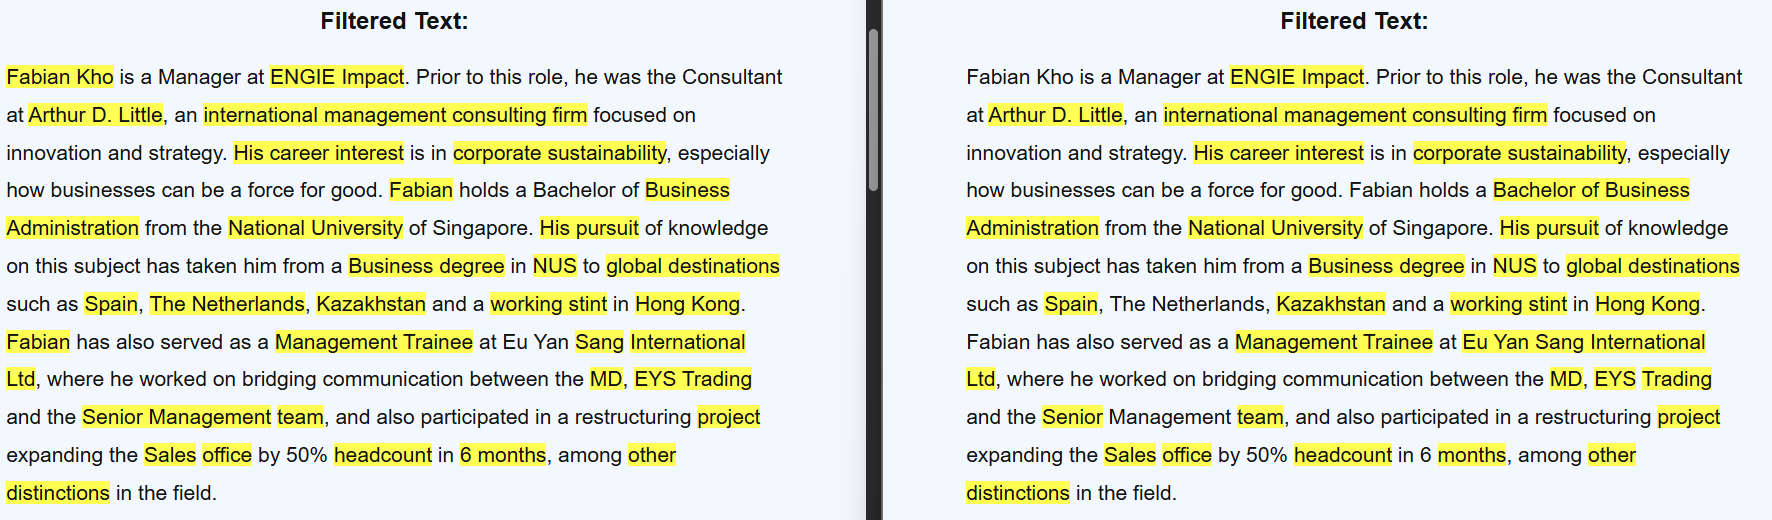

In [ ]:
# randomly chosen description
RANDOM_IDX = 483
random_row = df.iloc[RANDOM_IDX]

print('Bio:')
print(random_row['full_bio'])
print('')

print('Keywords:')
print(''.join(random_row['combined_keywords'][1:-1].strip().replace("'",'')))
print('')

print('Processed Keywords:')
print(', '.join(random_row['processed_keywords']))
print('')

Bio:
Wei Lim is a Management Consultant with Kearney, where he has worked across geographies such as the US, Middle East and Southeast Asia, as well as across industries, ranging from digital media and telecommunications to transportation, logistics and consumer goods packaging. Prior to management consulting, Wei Lim had spent 5 years in the media and entertainment industry. Today, he still records and mixes music in his free time, with a passion for microphones and synthesizers. He holds a Diploma in Piano Performance from ABRSM. Wei Lim graduated from the University of Michigan with a Bachelor of Science in Brain Behaviour and Cognitive Science as well as in Sound Engineering. He completed his Master's Degree in Business Administration, Strategy, Economics and Marketing at Carnegie Mellon University.

Keywords:
middle east, cognitive, "his master s degree", management consultant, mellon, brain, years, Southeast Asia, business administration, media entertainment industry, transportat

Left Before, Right After text processing

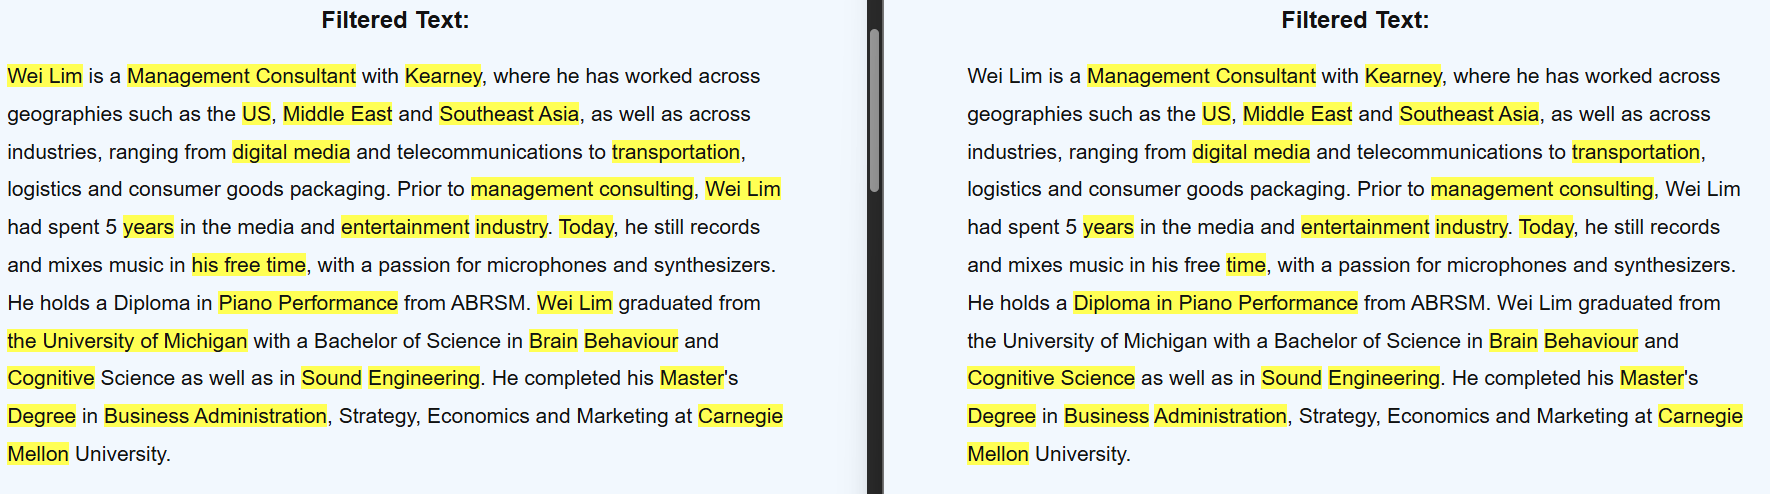

In [ ]:
import matplotlib.pyplot as plt

count    4449.000000
mean       36.338953
std         4.566625
min         0.000000
25%        34.000000
50%        36.000000
75%        39.000000
max        58.000000
Name: keyword_count, dtype: float64


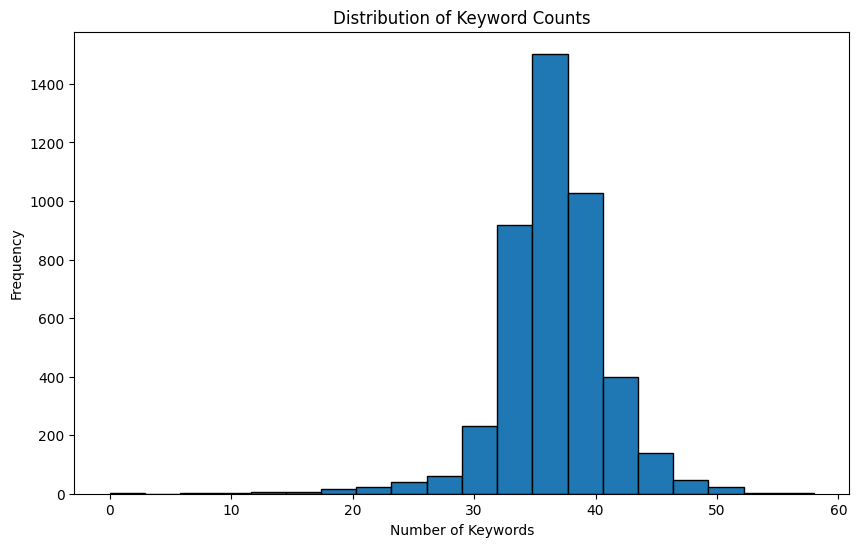

In [ ]:
# Calculate the number of keywords in each row
df['keyword_count'] = df['processed_keywords'].apply(len)

print(df['keyword_count'].describe())

# Create a histogram of the keyword counts
plt.figure(figsize=(10, 6))
plt.hist(df['keyword_count'], bins=20, edgecolor='black')
plt.xlabel('Number of Keywords')
plt.ylabel('Frequency')
plt.title('Distribution of Keyword Counts')
plt.show()

In [ ]:
# Calculate the total sum of keywords
total_keywords = df['keyword_count'].sum()
total_rows = len(df)
mean_keywords = df['keyword_count'].mean()

print(f"Total number of keywords across all rows: {total_keywords}")
print(f"Total number of rows in the DataFrame: {total_rows}")
print(f"Mean keywords per row: {mean_keywords:.2f}")

Total number of keywords across all rows: 161672
Total number of rows in the DataFrame: 4449
Mean keywords per row: 36.34


In [ ]:
# Aggregate all keywords
all_keywords = []
for index, row in df.iterrows():
  if not pd.isna(row['full_bio']):
      keywords = row['processed_keywords']
      all_keywords.extend(keywords)

all_keywords_unique = list(set(all_keywords))

In [ ]:
print(f"Total number of unique keywords: {len(all_keywords_unique)}")
print(f"Total number of keywords in the combined list: {len(all_keywords)}")

Total number of unique keywords: 36907
Total number of keywords in the combined list: 161672


In [ ]:
# randomly sampling for sanity check
all_keywords_unique[:10]

['people analyst',
 'portfolio strategic governance',
 'political reporter',
 'operator relations manager',
 'advocacy program',
 'peak',
 'villagers',
 'large',
 'islands',
 'certified professional logistician']

In [ ]:
!pip install wordcloud matplotlib

In [ ]:
from wordcloud import WordCloud

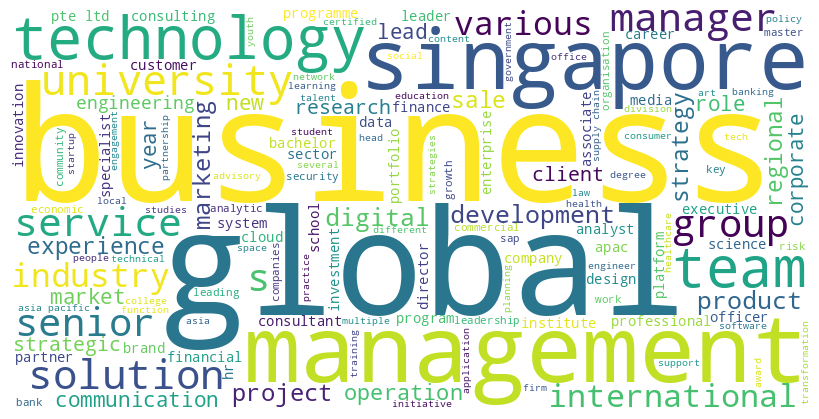

In [ ]:
# Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    min_font_size=10
).generate(' '.join(all_keywords_unique))

# Display the generated image:
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [ ]:
import csv

In [ ]:
csv_file_path = 'unique_mentor_keywords_with_substrings.csv'

try:
    with open(csv_file_path, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        # Write a header row (optional)
        writer.writerow(['keyword'])
        # Write each keyword as a new row
        for keyword in all_keywords_unique:
            writer.writerow([keyword])
    print(f"Successfully stored unique keywords in '{csv_file_path}'")
except Exception as e:
    print(f"An error occurred while writing to CSV: {e}")

Successfully stored unique keywords in 'unique_mentor_keywords_with_substrings.csv'


In [ ]:
# Finding elements where bio is NaN

# Sort the DataFrame by keyword count in ascending order
df_sorted = df.sort_values(by='keyword_count')

result_df = df_sorted[(df_sorted['full_bio'].isna()) | (df_sorted['combined_keywords'] == 1)]
result_df

,id,full_bio,combined_keywords,name,processed_keywords,keyword_count
1796,rec0aAmejuxjcS0Cc,NaN,[],Sanjay Chaudhari,[],0
630,recQOmQp80Tme96Xm,NaN,[],Krishna Anand,[],0
2044,recRin4Y1qag1tRGF,NaN,[],Loveet Kumar,[],0
